# Formatos de etiquetas en Machine Learning

Documentación: https://scikit-learn.org/stable/modules/multiclass.html

## Introducción

En Machine Learning, las **etiquetas** (labels) representan la variable objetivo que el modelo intenta predecir.  
El formato elegido para estas etiquetas afecta directamente:

- El tipo de modelo que puede utilizarse
- La función de pérdida
- El consumo de memoria
- La interpretación matemática del problema

Los formatos más comunes son:

- Vector unidimensional (1D)
- Matriz binaria (densa o sparse)

---

## Vector de etiquetas 1D

Un **vector de etiquetas 1D** asigna un único valor escalar a cada muestra del conjunto de datos.

### Representación matemática

$$
\mathbf{y} \in \mathbb{R}^{n}
$$

donde $n$ es el número de muestras.

### Ejemplo conceptual

En un problema de clasificación con $3$ clases:

- $0$: Gato  
- $1$: Perro  
- $2$: Pájaro  

las etiquetas pueden representarse como:

$$
\mathbf{y} = [0, 1, 2, 1, 0, 2]
$$

### Casos de uso

- Clasificación binaria
- Clasificación multiclase (una clase por muestra)
- Regresión

### Ventajas y desventajas

**Ventajas**
- Representación simple
- Bajo consumo de memoria
- Compatible con modelos clásicos

**Desventajas**
- No siempre compatible con redes neuronales
- No apto para problemas multilabel

---


In [2]:
import numpy as np
y = np.array(['apple', 'pear', 'apple', 'orange'])
print(y)
print(type(y))

['apple' 'pear' 'apple' 'orange']
<class 'numpy.ndarray'>



## Matriz binaria de etiquetas (One-Hot Encoding)

En la representación **one-hot**, cada clase corresponde a una dimensión distinta.

### Definición

Las etiquetas se organizan en una matriz donde:

- Cada fila representa una muestra
- Cada columna representa una clase
- El valor $1$ indica la clase correcta
- El valor $0$ indica ausencia de la clase

### Representación matemática

$$
\mathbf{Y} \in \{0,1\}^{n \times k}
$$

donde:
- $n$ es el número de muestras  
- $k$ es el número de clases  

### Ejemplo conceptual

Para $k = 3$ clases:

| Gato | Perro | Pájaro |
|------|-------|--------|
| $1$ | $0$ | $0$ |
| $0$ | $1$ | $0$ |
| $0$ | $0$ | $1$ |
| $0$ | $1$ | $0$ |

Cada fila contiene exactamente un valor igual a $1$.

### Uso típico

Este formato es el más utilizado en redes neuronales junto con **softmax** y **entropía cruzada categórica**.

### Ventajas y desventajas

**Ventajas**
- Representación explícita de las clases
- Ideal para modelos basados en gradiente
- Evita imponer un orden artificial

**Desventajas**
- Alto consumo de memoria cuando $k$ es grande
- Muchas operaciones con ceros

---

## Matriz binaria sparse

Cuando el número de clases $k$ es grande, la mayoría de los valores de la matriz one-hot son ceros.  
Para estos casos se utiliza una **representación sparse**.

### Idea principal

En lugar de almacenar todos los ceros, solo se guardan los valores distintos de cero.

Por ejemplo, en lugar de:

$$
[0, 0, 0, 1, 0, 0, 0]
$$

se almacena:

$$
(\text{índice} = 3,\ \text{valor} = 1)
$$

### Casos de uso

- Procesamiento de lenguaje natural (NLP)
- Sistemas de recomendación
- Clasificación con miles de clases

### Ventajas y desventajas

**Ventajas**
- Uso eficiente de memoria
- Escalable a grandes dimensiones

**Desventajas**
- No todos los modelos aceptan matrices sparse
- A veces requiere conversión a formato denso

---


In [4]:
import numpy as np
from sklearn.preprocessing import LabelBinarizer
y = np.array(['apple', 'pear', 'apple', 'orange'])
y

array(['apple', 'pear', 'apple', 'orange'], dtype='<U6')

In [5]:
y_dense = LabelBinarizer().fit_transform(y)
y_dense

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0]])

In [6]:
from scipy import sparse
y_sparse = sparse.csr_matrix(y_dense)
print(y_sparse)

  (0, 0)	1
  (1, 2)	1
  (2, 0)	1
  (3, 1)	1



## Etiquetas multilabel (Multi-Hot Encoding)

En los problemas **multilabel**, una muestra puede pertenecer a varias clases al mismo tiempo.

### Representación

La matriz de etiquetas mantiene la forma:

$$
\mathbf{Y} \in \{0,1\}^{n \times k}
$$

pero permite múltiples valores $1$ por fila.

### Ejemplo conceptual

Clases: $\{\text{Gato}, \text{Perro}, \text{Pájaro}\}$

| Gato | Perro | Pájaro |
|------|-------|--------|
| $1$ | $1$ | $0$ |
| $0$ | $0$ | $1$ |
| $1$ | $0$ | $0$ |
| $0$ | $1$ | $1$ |

### Diferencia clave

- **Multiclase**: una sola clase por muestra  
- **Multilabel**: múltiples clases por muestra  

---

## Comparación de formatos

| Formato | Dimensión | Uso típico |
|--------|-----------|-----------|
| Vector 1D | $(n,)$ | Modelos clásicos |
| One-Hot | $(n, k)$ | Redes neuronales |
| Sparse | $(n, k)$ sparse | Muchas clases |
| Multi-Hot | $(n, k)$ | Multilabel |

---

## Conclusiones

La elección del formato de las etiquetas es fundamental en cualquier sistema de Machine Learning.

- El **vector 1D** es simple y eficiente
- La **matriz binaria** es necesaria para deep learning
- La representación **sparse** es clave para problemas a gran escala
- Los problemas **multilabel** requieren matrices multi-hot

**Regla práctica**: el formato de las etiquetas debe elegirse en función del modelo y de la función de pérdida.

## Regresión multisalida (Multi-Output Regression)

En problemas de **regresión multisalida**, cada muestra tiene **varios valores objetivos** simultáneamente.  
Esto es útil cuando queremos predecir múltiples variables continuas que pueden estar correlacionadas.

### Representación matemática

Si tenemos $n$ muestras y $m$ salidas continuas por muestra, las etiquetas se representan como:

$$
\mathbf{Y} \in \mathbb{R}^{n \times m}
$$

Cada fila $\mathbf{y}_i$ corresponde a una muestra, y cada columna a una variable de salida.

### Ejemplo conceptual

Supongamos que queremos predecir **altura y peso** de varias personas:

$$
\mathbf{Y} =
\begin{bmatrix}
170 & 65 \\
180 & 75 \\
160 & 55 \\
175 & 70
\end{bmatrix}
$$

- La primera columna es la altura  
- La segunda columna es el peso

### Casos de uso

- Predicción de múltiples propiedades físicas de un objeto
- Series temporales multivariadas
- Predicción simultánea de varias características financieras

### Ventajas y desventajas

**Ventajas**
- Captura correlaciones entre variables de salida
- Permite entrenar un solo modelo para múltiples objetivos

**Desventajas**
- Puede requerir más datos para entrenar adecuadamente
- Algunas métricas de evaluación deben adaptarse a múltiples salidas (p.ej., MAE o MSE por salida)

### Relación con formatos de etiquetas

- Cada salida continua se representa como una columna en la matriz de etiquetas  
- Este formato es conceptualmente similar al vector 1D, pero **extendido a varias columnas**
- No se usa one-hot ni sp

## Clasificación multisalida (Multi-Output Classification)

En la **clasificación multisalida**, cada muestra tiene **varias variables de salida categóricas**, independientes entre sí.  
Esto es útil cuando queremos predecir **varias etiquetas discretas** al mismo tiempo.

### Representación matemática

Si tenemos $n$ muestras y $m$ salidas, cada una con $k_j$ clases, las etiquetas se pueden representar como:

$$
\mathbf{Y} \in \{0,1\}^{n \times \sum_{j=1}^{m} k_j}
$$

- Cada salida puede ser codificada en **one-hot**  
- Todas las salidas juntas forman una matriz ancha, o alternativamente **una lista de vectores** por salida.

### Ejemplo conceptual

Supongamos un problema con dos predicciones por muestra:

1. Color: {Rojo, Verde, Azul} → 3 clases  
2. Forma: {Círculo, Cuadrado} → 2 clases  

Una muestra podría representarse con:

$$
\text{Color: [0,1,0], Forma: [1,0]}
$$

La matriz final de etiquetas (para varias muestras) sería:

| Color R | Color V | Color A | Forma Círculo | Forma Cuadrado |
|---------|---------|---------|---------------|----------------|
| 0       | 1       | 0       | 1             | 0              |
| 1       | 0       | 0       | 0             | 1              |
| 0       | 0       | 1       | 1             | 0              |

### Casos de uso

- Predicción de múltiples propiedades categóricas de un objeto
- Sistemas de etiquetado automático con varias categorías
- Diagnóstico médico con múltiples resultados posibles

### Ventajas y desventajas

**Ventajas**
- Permite predecir varias etiquetas simultáneamente
- Puede capturar correlaciones entre las salidas

**Desventajas**
- Requiere más memoria y datos para entrenar  
- La estructura de la matriz de etiquetas puede ser compleja
arse, ya que no hay clases, sino valores continuos



**MAPA GUÍA:** https://scikit-learn.org/1.3/tutorial/machine_learning_map/

# Estrategias para Clasificación Multiclase: One-vs-All y One-vs-One

En problemas de clasificación multiclase, muchos algoritmos funcionan **solo para dos clases** (binarios).  
Para adaptarlos a $K$ clases se utilizan estrategias como:

- **One-vs-All (OvA)** o **One-vs-Rest (OvR)**  
- **One-vs-One (OvO)**

> Nota: One-vs-All y One-vs-Rest son **sinónimos**.

---
## 1. One-vs-All / One-vs-Rest (OvA / OvR)

### Idea principal

Se entrena un **clasificador binario por clase**:

- Positivo: muestras de la clase $C_i$  
- Negativo: todas las demás clases  

Luego, para predecir una nueva muestra, se selecciona la clase cuyo clasificador devuelve **mayor probabilidad**.

### Fórmula

Sea $f_i(x)$ la salida del clasificador para clase $C_i$:

$$
f_i(x) = P(y = C_i \mid x)
$$

Predicción final:

$$
\hat{y} = \arg\max_{i \in \{1,\dots,K\}} f_i(x)
$$

### Ejemplo concreto

Clases: Gato, Perro, Pájaro

| Clasificador | Positivo | Negativo |
|--------------|----------|----------|
| $f_1$        | Gato     | Perro, Pájaro |
| $f_2$        | Perro    | Gato, Pájaro  |
| $f_3$        | Pájaro   | Gato, Perro  |

Nueva muestra $x$:

- $f_1(x) = 0.7$, $f_2(x) = 0.2$, $f_3(x) = 0.1$  
- Predicción: **Gato** (mayor probabilidad)

### Ventajas

- Fácil de implementar con cualquier clasificador binario  
- Escalable a muchas clases  

### Desventajas

- Cada clasificador independiente → posibles incoherencias  
- Puede haber **desequilibrio de clases** en cada binario

---

## 2. One-vs-One (OvO)

### Idea principal

Se entrena un clasificador **por cada par de clases**:

- Para $K$ clases, el número de clasificadores es:

$$
\text{NUMclasificadores} = \frac{K(K-1)}{2}
$$

- Cada clasificador decide **solo entre dos clases**  
- La predicción final se realiza por **votación** (la clase con más “ganadas”)

### Ejemplo concreto

Clases: Gato, Perro, Pájaro ($K=3$)

Clasificadores:

- Gato vs Perro  
- Gato vs Pájaro  
- Perro vs Pájaro  

Predicciones de un ejemplo:

| Clasificador     | Predicción |
|-----------------|------------|
| Gato vs Perro   | Gato       |
| Gato vs Pájaro  | Pájaro     |
| Perro vs Pájaro | Perro      |

- Votos: Gato=1, Perro=1, Pájaro=1 → empate  
- Se puede desempatar usando probabilidad promedio o prioridad predefinida

### Ventajas

- Clasificadores balanceados (menos desequilibrio)  
- Mejor rendimiento en algunos problemas multiclase

### Desventajas

- Número de modelos crece rápido: $K(K-1)/2$  
- Entrenamiento más costoso

---

## 3. Comparativa OvA vs OvO

| Estrategia | # Clasificadores | Ventaja | Desventaja |
|------------|----------------|---------|------------|
| One-vs-All / One-vs-Rest | $K$ | Simple, fácil de implementar | Desequilibrio de clases, posibles inconsistencias |
| One-vs-One | $K(K-1)/2$ | Cada clasificador balanceado | Más modelos → entrenamiento costoso |

---


## 4. Resumen de fórmulas

### One-vs-All / One-vs-Rest

$$
f_i(x) = P(y = C_i \mid x), \quad i = 1..K
$$

$$
\hat{y} = \arg\max_i f_i(x)
$$


### One-vs-One

Número de clasificadores:

$$
\text{NUMclasificadores} = \frac{K(K-1)}{2}
$$

Predicción final:

$$
\hat{y} = \text{clase con más votos entre los clasificadores}
$$


# Función de Coste y Descenso de Gradiente en Machine Learning

## 1. Introducción

En Machine Learning, entrenar un modelo significa **ajustar sus parámetros** para minimizar el error entre las predicciones y los valores reales.  
Esto se formaliza usando:

- **Función de coste (loss function)**: mide el error del modelo  
- **Algoritmo de optimización**: ajusta los parámetros para minimizar la función de coste  

El método más común de optimización es **descenso de gradiente**.

---

## 2. Función de Coste

La **función de coste** cuantifica qué tan bien se ajusta un modelo a los datos.  

### 2.1. Clasificación binaria

Usamos la **entropía cruzada (binary cross-entropy)**:

$$
J(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \Big[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \Big]
$$

- $n$: número de muestras  
- $y_i$: etiqueta real (0 o 1)  
- $\hat{y}_i$: predicción del modelo  
- $\theta$: parámetros del modelo

### 2.2. Regresión

Usamos el **error cuadrático medio (MSE)**:

$$
J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

- Penaliza más los errores grandes  
- Es diferenciable, ideal para gradiente

### 2.3. Multiclase (softmax)

Para clasificación multiclase:

$$
J(\theta) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log(\hat{y}_{i,k})
$$

- $y_{i,k}$: 1 si la muestra $i$ pertenece a la clase $k$, 0 en otro caso  
- $\hat{y}_{i,k}$: probabilidad predicha por el modelo

---

## 3. Descenso de Gradiente

El **descenso de gradiente** es un algoritmo para **minimizar la función de coste**.  

### 3.1. Idea principal

1. Inicializamos los parámetros $\theta$ aleatoriamente  
2. Calculamos la derivada (gradiente) de la función de coste respecto a $\theta$  
3. Actualizamos los parámetros en la **dirección opuesta al gradiente**:

$$
\theta := \theta - \alpha \nabla_\theta J(\theta)
$$

- $\alpha$: tasa de aprendizaje (learning rate)  
- $\nabla_\theta J(\theta)$: gradiente de la función de coste

---

### 3.2. Tipos de Descenso de Gradiente

1. **Batch Gradient Descent**  
   - Calcula el gradiente usando **todas las muestras**  
   - Estable, pero lento con datasets grandes

2. **Stochastic Gradient Descent (SGD)**  
   - Calcula el gradiente usando **una sola muestra** a la vez  
   - Más ruidoso, pero más rápido y puede escapar de mínimos locales

3. **Mini-Batch Gradient Descent**  
   - Calcula el gradiente usando **un pequeño subconjunto** de muestras  
   - Combina estabilidad y eficiencia

---

## 4. Ejemplo conceptual (Regresión Lineal)

Supongamos un modelo lineal:

$$
\hat{y} = \theta_0 + \theta_1 x
$$

Función de coste (MSE):

$$
J(\theta_0, \theta_1) = \frac{1}{n} \sum_{i=1}^{n} (\theta_0 + \theta_1 x_i - y_i)^2
$$

Gradientes parciales:

$$
\frac{\partial J}{\partial \theta_0} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_i
$$

Actualización de parámetros:

$$
\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0}
$$

$$
\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}
$$

---

## 5. Visualización conceptual

- La función de coste se puede imaginar como una **superficie 3D** en $\theta_0$ y $\theta_1$  
- El **descenso de gradiente** es como “bajar por la pendiente” hasta el mínimo



--

## 6. Resumen

| Concepto | Fórmula / Idea |
|----------|----------------|
| Función de coste (MSE) | $J(\theta) = \frac{1}{n} \sum (\hat{y}_i - y_i)^2$ |
| Función de coste (BCE) | $J(\theta) = -\frac{1}{n} \sum y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)$ |
| Función de coste (Softmax) | $J(\theta) = -\frac{1}{n} \sum \sum y_{i,k} \log(\hat{y}_{i,k})$ |
| Gradiente | $\nabla_\theta J(\theta)$ |
| Descenso de gradiente | $\theta := \theta - \alpha \nabla_\theta J(\theta)$ |
| Tipos | Batch, Stochastic, Mini-Batch |

---

💡 **Tip práctico**:  
- Elegir la función de coste según el problema: MSE para regresión, BCE/Softmax para clasificación  
- Ajustar la **tasa de aprendizaje** $\alpha$ para estabilidad y rapidez  
- Mini-batch es el estándar en deep learning


# Modelos de regresión

## Puntuación de varianza explicada

La **puntuación de varianza explicada** mide qué proporción de la **dispersión de los datos observados** es capturada por el modelo.  

Se define como:

$$
\text{Explained Variance Score} = 1 - \frac{\text{Var}(y - \hat{y})}{\text{Var}(y)}
$$

donde:  
- $y$ son los valores observados.  
- $\hat{y}$ son los valores predichos por el modelo.  
- $\text{Var}$ indica la varianza.

---


### Interpretación

- Si el modelo predice perfectamente: $y = \hat{y} \Rightarrow \text{Var}(y - \hat{y}) = 0$, entonces **Explained Variance = 1** → el modelo explica toda la varianza.  
- Si el modelo predice mal, los errores son grandes → **Explained Variance ≈ 0**.  
- Si el modelo es peor que predecir la media → **Explained Variance < 0**.

💡 En palabras simples:  

> **“Explicar la varianza”** significa **qué tanto de la dispersión real de los datos logra reproducir el modelo**.  
> - Valores cercanos a 1: el modelo sigue muy bien los cambios en los datos.  
> - Valores cercanos a 0: el modelo apenas captura la dispersión.  
> - Valores negativos: el modelo empeora al predecir, incluso comparado con usar la media.


**Ejemplo**

Supongamos que tenemos los siguientes datos:

| Observado ($y$) | Predicho ($\hat{y}$) |
|-----------------|---------------------|
| 3               | 2.8                 |
| 5               | 4.9                 |
| 2               | 2.1                 |
| 7               | 6.8                 |


In [20]:
from sklearn.metrics import explained_variance_score
import numpy as np

In [21]:
y_true = np.array([3,5,2,7])
y_pred = np.array([2.8,4.9, 2.1,6.8])

1. **Varianza de los errores (residuos):** La varianza de los errores mide cuánto se equivoca el modelo en promedio respecto a los valores reales.

$$
\text{Var}(y - \hat{y}) = 0.015000000000000027
$$

In [23]:
residuos = y_true - y_pred
var_residuos = np.var(residuos)
var_residuos

0.015000000000000027

2. **Varianza de los valores observados:** La varianza de los errores mide cuánto se equivoca el modelo en promedio respecto a los valores reales.
$$
\text{Var}(y) = 3.6875
$$




In [25]:
var_y = np.var(y_true)
var_y

3.6875

3. **Puntuación de varianza explicada:**

$$
\text{Explained Variance Score} = 1 - \frac{0.015000000000000027}{3.6875} \approx 0.995
$$

---

In [27]:
explained_variance_score_calculada = 1-(var_residuos/var_y)
explained_variance_score_calculada

0.9959322033898305

Para no realizar el cálculo manual, te haría ocupando <code> explained_variance_score </code>

In [29]:
explained_variance_score(y_true, y_pred)

0.9959322033898305

 > El modelo **predice casi perfectamente los cambios en los datos observados**, y los errores de predicción son muy pequeños en relación con la variabilidad total de los datos.


## Error máximo


El **error máximo** se define como:

$$
\text{Max Error} = \max_i \, |y_i - \hat{y}_i|
$$

donde:  
- $y_i$ es el valor observado.  
- $\hat{y}_i$ es el valor predicho por el modelo.  
- $\max_i$ indica que tomamos el **mayor valor absoluto de los errores** entre todas las observaciones.

**Interpretación:**  
- Indica **el peor error que comete el modelo** en cualquier predicción.  
- Es útil para detectar **predicciones extremadamente malas** o outliers en regresión.


El valor ideal es 0.

In [34]:
from sklearn.metrics import max_error

In [35]:
y_true = [3, 2, 20, 1]
y_pred = [4, 2, 7, 1]

In [36]:
max_error(y_true, y_pred)

13

## Error absoluto medio (MAE)



El **Error Absoluto Medio (MAE)** se define como:

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

donde:  
- $y_i$ es el valor observado.  
- $\hat{y}_i$ es el valor predicho por el modelo.  
- $n$ es el número de observaciones.  
- $|\cdot|$ indica el **valor absoluto** del error.

**Interpretación:**  
- Representa el **error promedio de las predicciones** en las mismas unidades que los datos.  
- A diferencia del error cuadrático, **no penaliza excesivamente los errores grandes**, por lo que es más robusto frente a outliers.  
- Valores más pequeños de MAE indican **mejor ajuste del modelo**.


> Cuanto más pequeño, mejor.

In [40]:
from sklearn.metrics import mean_absolute_error

In [41]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

In [42]:
sum(abs(y_true-y_pred))/len(y_true)

0.5

Para no hacerlo de manera manual, ocupamos <code> mean_absolute_error </code>

In [44]:
mean_absolute_error(y_true, y_pred)

0.5

En resumen: **el valor final 0.5 es el error promedio absoluto de tus predicciones**.  
Es decir, tus predicciones, en promedio, se alejan **0.5 unidades** de los valores reales.

## Error cuadrático medio (MSE)

El **Error Cuadrático Medio (MSE – Mean Squared Error)** mide el **promedio de los errores al cuadrado** entre los valores observados y los predichos:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

donde:  
- $y_i$ son los valores observados.  
- $\hat{y}_i$ son los valores predichos por el modelo.  
- $n$ es el número de observaciones.

**Interpretación:**  
- Penaliza más los errores grandes que los pequeños (por estar al cuadrado).  
- Valores más bajos indican **mejor ajuste del modelo**.  
- A diferencia del MAE, el MSE amplifica el efecto de outliers.

> Cuanto más pequeño, mejor.

In [50]:
from sklearn.metrics import mean_squared_error

In [51]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 28])

In [52]:
y_true

array([ 3. , -0.5,  2. ,  7. ])

In [53]:
y_pred

array([ 2.5,  0. ,  2. , 28. ])

In [54]:
(sum((y_true - y_pred)**2))/len(y_true)

110.375

Para no hacer el cálculo manual, lo hacemos con <code>  mean_squared_error </code>

In [56]:
mean_squared_error(y_true, y_pred)

110.375

**Interpretación del resultado**

- El MSE = 0.375 indica el promedio de los errores al cuadrado de las predicciones.

- Como los errores se elevan al cuadrado, los errores más grandes tienen un mayor impacto en el MSE que en el MAE.

- Cuanto más cercano a 0 sea el MSE, mejor ajuste tiene el modelo.

## Raíz del error cuadrático medio (RMSE)

El **RMSE (Root Mean Squared Error)** es la **raíz cuadrada del Error Cuadrático Medio (MSE)** y mide el **error típico de las predicciones** en las **mismas unidades que la variable objetivo**.

Se define como:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

donde:  
- $y_i$ son los valores observados.  
- $\hat{y}_i$ son los valores predichos por el modelo.  
- $n$ es el número de observaciones.

---


- Cuanto más pequeño, mejor.

In [61]:
y_true

array([ 3. , -0.5,  2. ,  7. ])

In [62]:
y_pred

array([ 2.5,  0. ,  2. , 28. ])

In [63]:
mean_squared_error(y_true, y_pred, squared = False)

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


10.505950694725348

## Error logarítmico cuadrático medio (MSLE)

El **MSLE (Mean Squared Logarithmic Error)** mide el promedio del **error cuadrático entre los logaritmos** de los valores observados y los predichos.

Se define como:

$$
\text{MSLE} = \frac{1}{n} \sum_{i=1}^{n}
\left( \log(1 + y_i) - \log(1 + \hat{y}_i) \right)^2
$$

donde:  
- $y_i$ son los valores observados.  
- $\hat{y}_i$ son los valores predichos.  
- $n$ es el número de observaciones.  
- Se usa $\log(1 + x)$ para evitar problemas cuando $x = 0$.

⚠️ **Restricción importante:**  
MSLE **solo puede usarse cuando $y_i \ge 0$ y $\hat{y}_i \ge 0$**.

Es especialmente útil en problemas como:

- Predicción de ventas

- Crecimiento poblacional

- Modelos financieros

- Series temporales con tendencia exponencial

---

**¿Qué mide el MSLE?**

- Penaliza **errores relativos**, no absolutos.  
- Castiga más **subestimar** que **sobreestimar**.  
- Es ideal cuando los valores reales crecen de forma **exponencial** o tienen grandes diferencias de escala.
-  Esta métrica es más apropiada para casos en que la variable objetivo tiene un crecimiento exponencial, como el recuento de la población, las ventas promedio de un producto durante un periodo de años, etc.

---

> Cuanto más pequeño, mejor.


**Ejemplo: MSLE en predicción de precios de casas**

En problemas de **predicción de precios de casas**, los valores pueden variar mucho entre viviendas baratas y caras.  
En estos casos, medir solo el error absoluto puede ser engañoso, por lo que el **MSLE** es una métrica más adecuada al centrarse en **errores relativos**.

---

**Datos del ejemplo**

Supongamos los siguientes precios (en miles de dólares):

- Precios reales:  
  $y = [100,\ 200,\ 1000]$
- Precios predichos:  
  $\hat{y} = [150,\ 180,\ 900]$

---


**Errores absolutos**

| Casa | Precio real | Precio predicho | Error absoluto |
|------|-------------|-----------------|----------------|
| 1    | 100         | 150             | 50             |
| 2    | 200         | 180             | 20             |
| 3    | 1000        | 900             | 100            |

Con métricas como **MSE o RMSE**, el error de la casa más cara domina el resultado, aunque proporcionalmente no sea el peor error.

---

**Cálculo del MSLE**

La métrica MSLE se define como:

$$
\text{MSLE} = \frac{1}{n} \sum_{i=1}^{n}
\left( \log(1 + y_i) - \log(1 + \hat{y}_i) \right)^2
$$

**Paso 1: Aplicar el logaritmo**

Se aplica $\log(1 + x)$ a los precios reales y predichos para:
- Reducir la influencia de valores grandes.
- Medir errores proporcionales.

In [70]:
y_true = np.array([100, 200, 1000])
y_pred = np.array([150, 180, 900])
log_true = np.log1p(y_true)
log_pred = np.log1p(y_pred)
print(f"log(1 + ytrue_i) = {log_true}")
print(f"log(1 + ypred_i) = {log_pred }")

log(1 + ytrue_i) = [4.61512052 5.30330491 6.90875478]
log(1 + ypred_i) = [5.01727984 5.19849703 6.80350526]


**Paso 2: Calcular la diferencia logarítmica**

Esta diferencia mide el error **en escala relativa**:
- El error de pasar de 100 a 150 (50%) es más grave.
- Pasar de 100 a 150 es un error grande en porcentaje.
- Pasar de 1000 a 900 es un error pequeño en porcentaje.


In [72]:
errores_log = log_true - log_pred
errores_log

array([-0.40215932,  0.10480788,  0.10524952])

**Paso 3: Elevar al cuadrado**
Elevar al cuadrado:
- Elimina el signo del error.
- Penaliza más los errores proporcionales grandes.

In [74]:
errores_log_cuadrados = errores_log ** 2
errores_log_cuadrados

array([0.16173212, 0.01098469, 0.01107746])

**Paso 4: Promediar los errores**

El promedio de estos errores logarítmicos al cuadrado da como resultado el **MSLE**, que resume el desempeño del modelo en una sola medida.

In [76]:
msle = np.mean(errores_log_cuadrados)
msle

0.06126475716637231

**Conclusión**

- El **MSLE penaliza más los errores relativos grandes**, incluso si el error absoluto es pequeño.  
- Es especialmente útil en **predicción de precios de casas**, donde existen grandes diferencias de escala.  
- A diferencia de MSE o RMSE, el MSLE trata de forma más justa viviendas baratas y caras.

💡 **Cuando importa el porcentaje de error y no solo la diferencia absoluta, MSLE es la mejor elección.**

Para no calcularlo de manera manual, contamos con <code>  mean_squared_log_error </code>

In [84]:
from sklearn.metrics import mean_squared_log_error

mean_squared_log_error(y_true, y_pred)

0.06126475716637231

## Error absoluto mediano (MedAE)

La **MedAE (Median Absolute Error)** o **Error Absoluto Mediano** es una métrica utilizada para evaluar el rendimiento de modelos de **regresión**.

Mide el error típico del modelo tomando la **mediana** de los errores absolutos entre los valores reales y los valores predichos.

---

**Definición**

La MedAE calcula la mediana del valor absoluto de la diferencia entre el valor real y el valor predicho.

A diferencia de métricas como el **MAE** o el **MSE**, la MedAE es **robusta frente a valores atípicos (outliers)**, ya que la mediana no se ve afectada por errores extremos.

---


**Fórmula**

Sea $y_i$ el valor real y $\hat{y}_i$ el valor predicho, la MedAE se define como:

$$
\text{MedAE} = \text{median}(|y_i - \hat{y}_i|)
$$

---

**Interpretación**

- $\text{MedAE} = 0$ indica un modelo con predicciones perfectas.
- Cuanto **menor** sea la MedAE, **mejor** es el desempeño del modelo.
- Representa el **error típico** que comete el modelo.

---

**Ventajas**

- Robusta frente a outliers  
- Fácil de interpretar  
- Útil cuando los datos contienen valores extremos  
- Adecuada para problemas de regresión

---

**Desventajas**

- No penaliza fuertemente errores grandes  
- Puede ocultar la presencia de errores extremos importantes  
- Menos sensible que el MSE a grandes desviaciones

---

**Uso recomendado**

La MedAE es especialmente recomendable cuando:
- Existen outliers en el conjunto de datos  
- Se busca una métrica robusta  
- El error típico es más relevante que los errores extremos


> Cuanto más pequeño, mejor.

In [86]:
from sklearn.metrics import median_absolute_error

In [88]:
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]
median_absolute_error(y_true, y_pred)

0.5

## Coeficiente de determinación, R cuadrado

Representa la proporción de varianza de la variable objetivo que ha sido explicada por las variables independientes en el modelo. Proporciona una indicación de bondad de ajuste y, por lo tanto, de cómo de bien es probable que el modelo vaya a predecir nuevas muestras, a través de la proporción de varianza explicada.

Esta métrica se verá más en profundidad en la sección de modelos de regresión, más adelante.

## Otras métricas

Existen otras métricas apropiadas para evaluar el rendimiento de regresión, que no se tratarán aquí.

# Modelos de clasificación

## Exactitud (accuracy)

La **Accuracy** o **Exactitud** es una métrica utilizada en **problemas de clasificación**.

Mide la proporción de predicciones correctas respecto al total de observacione
La accuracy indica qué tan frecuentemente un modelo clasifica correctamente.*.s.

> Es una métrica intuitiva, pero puede ser **engañosa cuando los datos están desbalanceados**.

**Fórmula**

Sea:
- $TP$: Verdaderos Positivos  
- $TN$: Verdaderos Negativos  
- $FP$: Falsos Positivos  
- $FN$: Falsos Negativos  

La accuracy se define como:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


In [97]:
from sklearn.metrics import accuracy_score

In [99]:
y_true = [0, 1, 2, 3]
y_pred = [0, 2, 1, 3]

<code> normalize=False </code>

Devuelve la **proporción de predicciones correctas**

In [105]:
accuracy_score(y_true, y_pred, normalize=True)

0.5

<code> normalize=False </code>

Devuelve el número total de predicciones correctas, no el porcentaje.

In [103]:
accuracy_score(y_true, y_pred, normalize=False)

2.0

## Precisión (precision)

La **Precision** es una métrica utilizada en **problemas de clasificación**, especialmente cuando las clases están desbalanceadas.

Mide la proporción de **predicciones positivas correctas** respecto al total de predicciones positivas realizadas por el modelo.

**Definición**

La precision indica cuán confiables son las predicciones positivas del modelo.

Se enfoca solo en la clase positiva, ignorando los verdaderos negativos.


La precisión es el ratio tp / (tp + fp), donde tp es el número de verdaderos positivos y fp el número de falsos positivos. La precisión nos da una idea de la capacidad del modelo clasificador de no etiquetar como positiva una muestra que realmente es negativa.  
- La precisión nos da una idea de la capacidad del modelo clasificador de no etiquetar como positiva una muestra que realmente es negativa.

**Fórmula**

Sea:
- $TP$: Verdaderos Positivos  
- $FP$: Falsos Positivos  

La precision se define como:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$


> El mejor valor es un 1 y el peor, un 0.

In [117]:
from sklearn.metrics import precision_score
y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]

In [119]:
precision_score(y_true, y_pred, average=None)

array([0.66666667, 0.        , 0.        ])

Para la clase 0: 
- TP: I I
- Fp: I
P(clase_0) = 2/(2+1) = 0.66666667

Para la clase 1:
- Tp: 0
- Fp: I I
P(clase_1) = 0/(0+2) = 0

Para la clase 2:
- Tp: 0
- Fp: I
P(clase_2) = 0/(0+1) = 0

## Recuperación (recall)

El **Recall** es una métrica utilizada en **problemas de clasificación**, especialmente en datos desbalanceados.

Mide la proporción de **positivos reales correctamente identificados** por el modelo.

**Definición**

El recall indica **cuán bueno es el modelo para detectar todos los casos positivos**.

Se enfoca en los verdaderos positivos y los falsos negativos, ignorando los verdaderos negativos.


**Fórmula**

Sea:
- $TP$: Verdaderos Positivos  
- $FN$: Falsos Negativos  

El recall se define como:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


El mejor valor es un 1 y el peor, un 0.

In [124]:
from sklearn.metrics import recall_score

In [126]:
y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]

In [ ]:
recall_score(y_true, y_pred, average=None)

Para la clase 0:
- Tp: I I 
- Fn: 0
R(clase_0) = 2/(2+0) = 1

## Precisión promedio (average precision)

La **Precisión Promedio** es una métrica utilizada principalmente en **problemas de clasificación multiclase o de detección de objetos**.

Mide la **calidad de las predicciones ordenadas por probabilidad**, combinando **precision y recall** en un solo valor.


**Definición**

La Average Precision (AP) calcula la **área bajo la curva de precision-recall (PR curve)** para cada clase.  

Es decir, resume cómo varía la precision cuando se incrementa el recall a diferentes umbrales de decisión.


**Fórmula conceptual**

Para una clase positiva:

$$
AP = \sum_n (R_n - R_{n-1}) P_n
$$

Donde:

- $P_n$ es la precision en el punto $n$ de la curva PR  
- $R_n$ es el recall en el punto $n$
- La suma recorre todos los puntos donde cambia el recall


## Puntuación F1 

La **puntuación F1** combina **Precision** y **Recall** en una sola métrica.  
Es especialmente útil cuando se quiere un equilibrio entre **evitar falsos positivos** y **no perder positivos reales**.

El F1-score es la **media armónica** entre precision y recall:

- Da más importancia a los valores bajos (no permite que uno compense al otro)
- Va de 0 (peor) a 1 (mejor)

La puntuación F1 se define como la media armónica de la precisión y el recall, y se puede interpretar como un promedio ponderado de ambos. La contribución relativa de precisión y recall a la puntuación F1 es la misma. 

**Fórmula**

Sea:

- $P$: Precision  
- $R$: Recall  

El F1-score se define como:

$$
F1 = 2 \cdot \frac{P \cdot R}{P + R}
$$


> Una puntuación F1 alcanza su mejor valor en 1 y la peor puntuación en 0.

In [144]:
from sklearn.metrics import f1_score

In [146]:
y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]

In [148]:
f1_score(y_true, y_pred, average=None)

array([0.8, 0. , 0. ])

In [150]:
f1_score_0 = 2*(0.66666667*1.)/(0.66666667+1.)
f1_score_0

0.8000000023999999

## Pérdida logarítmica (log loss)

La pérdida logarítmica, también conocida como pérdida de regresión logística o pérdida de entropía cruzada, es la función de pérdida utilizada en la regresión logística (multinomial) y sus extensiones, como las redes neuronales, y se considera la métrica de clasificación basada en probabilidades más importante. 

La log loss se basa en una función de probabilidad. De hecho, Log Loss es -1 * el logaritmo de la función de probabilidad, la cual responde a la pregunta "¿cómo de probable pensó el modelo que era el conjunto de resultados realmente observado?". 

Cuanto más pequeña, mejor.

# Modelos de agrupamiento

## Mutual info score

La información mutua (MI) es una medida de la similitud entre dos etiquetas de los mismos datos. Donde |Ui| es el número de muestras en el cluster Ui y |Vj| es el número de muestras en el cluster Vj, la Información Mutua (Mutual Information) entre los clusters U y V viene dada como:

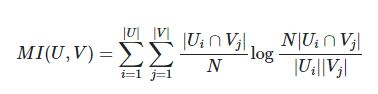

## Adjusted mutual info score

Indica la información mutua ajustada entre dos agrupaciones. La información mutua ajustada (AMI) es un ajuste de la Mutual Information (MI) para tener en cuenta el azar. Explica el hecho de que MI es generalmente más alta para dos agrupaciones con una mayor cantidad de agrupaciones, independientemente de si en realidad se comparte más información. Para dos agrupaciones y , el AMI se da como: